In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

In [2]:
# Load datasets

nav = pd.read_csv("../data/raw/02_nav_history.csv")
fund = pd.read_csv("../data/raw/01_fund_master.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# Convert date columns
nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

print(nav.shape)
print(fund.shape)
print(transactions.shape)
print(portfolio.shape)

(46000, 3)
(40, 15)
(32778, 13)
(322, 8)


In [3]:
# Sort data
nav = nav.sort_values(["amfi_code", "date"])

# Daily return
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav[["amfi_code","date","nav","daily_return"]].head(10))

      amfi_code       date       nav  daily_return
5750     100016 2022-01-03  520.4608           NaN
5751     100016 2022-01-04  515.0971     -0.010306
5752     100016 2022-01-05  521.7239      0.012865
5753     100016 2022-01-06  515.7880     -0.011377
5754     100016 2022-01-07  515.1639     -0.001210
5755     100016 2022-01-10  510.7136     -0.008639
5756     100016 2022-01-11  513.5542      0.005562
5757     100016 2022-01-12  512.3195     -0.002404
5758     100016 2022-01-13  510.2445     -0.004050
5759     100016 2022-01-14  514.3636      0.008073


In [4]:
# Historical VaR (95%) and CVaR

risk_results = []

for amfi in nav["amfi_code"].unique():

    returns = nav.loc[
        nav["amfi_code"] == amfi,
        "daily_return"
    ].dropna()

    if len(returns) > 0:

        # 5th percentile
        var95 = np.percentile(returns, 5)

        # Average of returns below VaR
        cvar95 = returns[returns <= var95].mean()

        risk_results.append([amfi, var95, cvar95])

risk_df = pd.DataFrame(
    risk_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

risk_df = risk_df.sort_values("VaR_95")

print(risk_df.head())
print(risk_df.shape)

    amfi_code    VaR_95   CVaR_95
22     119599 -0.026859 -0.032384
17     119095 -0.026188 -0.031667
4      101207 -0.026021 -0.032459
11     118634 -0.025438 -0.032304
21     119598 -0.024507 -0.030595
(40, 3)


In [5]:
risk_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("VaR & CVaR Report Saved Successfully")

VaR & CVaR Report Saved Successfully


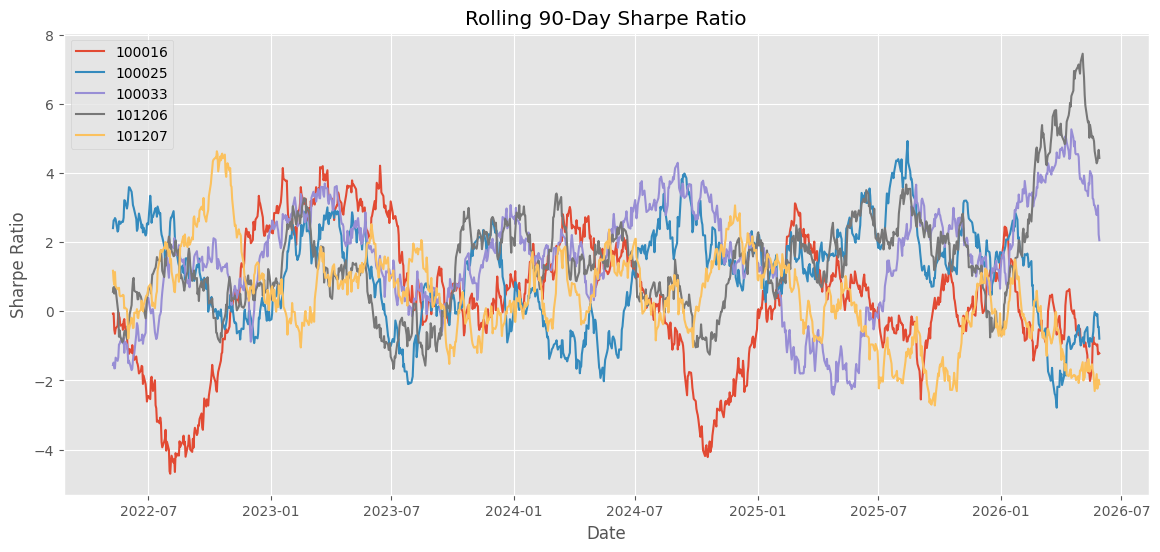

In [6]:
rolling_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(14,6))

for amfi in rolling_funds:

    temp = nav[nav["amfi_code"] == amfi].copy()

    temp = temp.sort_values("date")

    rolling_mean = temp["daily_return"].rolling(90).mean() * 252
    rolling_std = temp["daily_return"].rolling(90).std() * np.sqrt(252)

    temp["rolling_sharpe"] = rolling_mean / rolling_std

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(amfi)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig("../reports/rolling_sharpe_chart.png")

plt.show()

In [7]:
print("Rolling Sharpe Chart Saved Successfully")

Rolling Sharpe Chart Saved Successfully


In [8]:
# First transaction year for each investor

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = first_txn["transaction_date"].dt.year

transactions = transactions.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

In [11]:
top_fund = (
    transactions
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = top_fund.loc[
    top_fund.groupby("cohort_year")["count"].idxmax()
]

print(top_fund)

    cohort_year  amfi_code  count
35         2024     148568    874
62         2025     119599     12


In [10]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year']


In [14]:
# Keep only SIP transactions

sip = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

# Sort by investor and date
sip = sip.sort_values(["investor_id", "transaction_date"])

# Gap between SIPs
sip["gap_days"] = sip.groupby("investor_id")["transaction_date"].diff().dt.days

print(sip.head())

      investor_id transaction_date  amfi_code transaction_type  amount_inr  \
19621   INV000001       2024-11-04     120505              SIP       44856   
24448   INV000001       2025-01-19     125497              SIP        3090   
5650    INV000002       2024-03-29     149322              SIP        2830   
16803   INV000002       2024-09-21     120841              SIP        2354   
31881   INV000002       2025-05-17     119094              SIP        2690   

             state      city city_tier age_group gender  annual_income_lakh  \
19621      Haryana  Gurugram       T30     36-45   Male                19.9   
24448      Haryana  Gurugram       T30     36-45   Male                19.9   
5650   Maharashtra      Pune       T30     46-55   Male                24.0   
16803  Maharashtra      Pune       T30     46-55   Male                24.0   
31881  Maharashtra      Pune       T30     46-55   Male                24.0   

      payment_mode kyc_status  cohort_year  gap_days  
1

In [15]:
sip_count = sip.groupby("investor_id").size().reset_index(name="sip_count")

eligible = sip_count[sip_count["sip_count"] >= 6]

sip = sip.merge(
    eligible[["investor_id"]],
    on="investor_id"
)

print(sip.shape)

(9679, 15)


In [16]:
continuity = (
    sip.groupby("investor_id")
    .agg(
        avg_gap=("gap_days", "mean"),
        total_sips=("gap_days", "count")
    )
    .reset_index()
)

continuity["status"] = continuity["avg_gap"].apply(
    lambda x: "At Risk" if x > 35 else "Healthy"
)

print(continuity.head(10))

  investor_id    avg_gap  total_sips   status
0   INV000004  85.400000           5  At Risk
1   INV000008  70.400000           5  At Risk
2   INV000010  64.800000           5  At Risk
3   INV000011  40.166667           6  At Risk
4   INV000012  57.000000           7  At Risk
5   INV000013  55.333333           6  At Risk
6   INV000014  75.333333           6  At Risk
7   INV000023  58.571429           7  At Risk
8   INV000028  93.600000           5  At Risk
9   INV000029  60.666667           6  At Risk


In [17]:
recommend = sharpe_df.merge(
    fund[["amfi_code", "risk_category"]],
    on="amfi_code"
)

print(recommend.head())

NameError: name 'sharpe_df' is not defined

In [18]:
score = pd.read_csv("../reports/fund_scorecard.csv")

print(score.columns.tolist())
print(score.head())

['amfi_code', 'CAGR (%)', 'Sharpe Ratio', 'Alpha', 'Beta', 'Maximum Drawdown', 'CAGR_rank', 'Sharpe_rank', 'Alpha_rank', 'DD_rank', 'Fund Score']
   amfi_code   CAGR (%)  Sharpe Ratio     Alpha      Beta  Maximum Drawdown  \
0     120505  32.801599      1.180101  0.102647  1.194815         -0.181885   
1     148569  31.924486      1.234930  0.096473  1.174586         -0.163967   
2     100033  30.099704      1.093699  0.114423  0.991590         -0.162172   
3     148567  30.949920      1.448291  0.181968  0.557134         -0.112657   
4     119551  25.784921      1.208267  0.141513  0.562931         -0.150124   

   CAGR_rank  Sharpe_rank  Alpha_rank  DD_rank  Fund Score  
0        1.0          5.0         5.0     16.0      86.125  
1        4.0          3.0         8.0     20.0      81.125  
2        7.0          7.0         4.0     21.0      77.750  
3        5.0          1.0         1.0     33.0      77.000  
4       10.0          4.0         2.0     24.0      76.500  


In [19]:
print(fund.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [20]:
recommend = score.merge(
    fund[["amfi_code", "risk_category"]],
    on="amfi_code",
    how="left"
)

print(recommend.head())

   amfi_code   CAGR (%)  Sharpe Ratio     Alpha      Beta  Maximum Drawdown  \
0     120505  32.801599      1.180101  0.102647  1.194815         -0.181885   
1     148569  31.924486      1.234930  0.096473  1.174586         -0.163967   
2     100033  30.099704      1.093699  0.114423  0.991590         -0.162172   
3     148567  30.949920      1.448291  0.181968  0.557134         -0.112657   
4     119551  25.784921      1.208267  0.141513  0.562931         -0.150124   

   CAGR_rank  Sharpe_rank  Alpha_rank  DD_rank  Fund Score risk_category  
0        1.0          5.0         5.0     16.0      86.125          High  
1        4.0          3.0         8.0     20.0      81.125          High  
2        7.0          7.0         4.0     21.0      77.750          High  
3        5.0          1.0         1.0     33.0      77.000      Moderate  
4       10.0          4.0         2.0     24.0      76.500      Moderate  


In [21]:
def recommend_funds(risk_level):

    result = (
        recommend[
            recommend["risk_category"].str.upper() == risk_level.upper()
        ]
        .sort_values("Sharpe Ratio", ascending=False)
        .head(3)
    )

    return result[
        [
            "amfi_code",
            "risk_category",
            "Sharpe Ratio",
            "Fund Score"
        ]
    ]


print("LOW RISK")
print(recommend_funds("Low"))

print("\nMODERATE RISK")
print(recommend_funds("Moderate"))

print("\nHIGH RISK")
print(recommend_funds("High"))

LOW RISK
    amfi_code risk_category  Sharpe Ratio  Fund Score
29     120507           Low      0.495723      35.375
34     120844           Low     -0.088747      27.875
37     119120           Low     -0.226575      21.875

MODERATE RISK
   amfi_code risk_category  Sharpe Ratio  Fund Score
3     148567      Moderate      1.448291        77.0
4     119551      Moderate      1.208267        76.5
9     118632      Moderate      1.081659        70.0

HIGH RISK
   amfi_code risk_category  Sharpe Ratio  Fund Score
1     148569          High      1.234930      81.125
0     120505          High      1.180101      86.125
5     149323          High      1.132122      76.375


In [22]:
recommender_code = '''
import pandas as pd

def recommend_funds(df, risk_level):
    return (
        df[df["risk_category"].str.upper() == risk_level.upper()]
        .sort_values("Sharpe Ratio", ascending=False)
        .head(3)
    )
'''

with open("../recommender.py", "w") as f:
    f.write(recommender_code)

print("recommender.py created successfully!")

recommender.py created successfully!


In [23]:
# Sector HHI Concentration

portfolio["weight_pct"] = portfolio["weight_pct"] / 100

hhi = (
    portfolio
    .groupby("amfi_code")["weight_pct"]
    .apply(lambda x: (x**2).sum())
    .reset_index(name="HHI")
)

print(hhi.head())
print(hhi.shape)

   amfi_code       HHI
0     100016  0.139534
1     100033  0.147592
2     101206  0.129332
3     101207  0.200700
4     102885  0.174709
(34, 2)


In [24]:
hhi = hhi.sort_values("HHI", ascending=False)

print("Top Concentrated Funds")
print(hhi.head(10))

Top Concentrated Funds
    amfi_code       HHI
11     119092  0.206448
3      101207  0.200700
18     119599  0.174751
4      102885  0.174709
7      118632  0.168298
29     148568  0.167930
21     120505  0.157570
22     120506  0.153794
27     125498  0.152414
23     120841  0.149680


In [25]:
hhi.to_csv("../reports/hhi_report.csv", index=False)

print("HHI Report Saved Successfully")

HHI Report Saved Successfully


# Advanced Insights

## Insight 1
Funds with the highest VaR and CVaR indicate greater downside risk during volatile market conditions.

## Insight 2
Rolling Sharpe Ratio shows that risk-adjusted performance changes over time rather than remaining constant.

## Insight 3
Investor cohorts that started investing earlier have contributed higher cumulative investment amounts.

## Insight 4
Investors with SIP gaps greater than 35 days are classified as At-Risk and may require engagement.

## Insight 5
Funds with lower HHI values are more diversified, whereas higher HHI values indicate concentrated portfolios.